In [23]:
# %%
"""
Three triangle configurations for the Pareto morphospace figure.

Option 1 – Integration × Economy × Computation
    Classic conflict along the η axis: economy and integration strictly oppose
    each other; computation peaks near the edge-of-chaos in between.
    Directly mirrors the Fakhar 2025 finding.

Option 2 – Routing Efficiency × Diffusion Efficiency × Economy
    Replicates Avena-Koenigsberger et al. 2015 at 25k-network scale.
    Routing (shortest-path) and diffusion (random-walk) probe different
    aspects of connectivity; both conflict with wiring economy.

Option 3 – Composite Integration × Composite Economy × Composite Computation
    Uses the average of multiple normalized properties per optimization
    category, giving a more robust axis than any single property.
    Composite bounds are derived from the GNM dataset so all datasets
    are on the same absolute scale.
"""

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from vizman import viz

from config import COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES
from utils import get_combined_colors

# ── Data ─────────────────────────────────────────────────────────────────────

with open(
    "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/all_datasets_precise_categories.pkl",
    "rb",
) as f:
    dict_with_all_datasets = pickle.load(f)

output_folder = Path(
    "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs"
)
output_folder.mkdir(parents=True, exist_ok=True)

INCLUDE_LEXIS = True

datasets_to_plot = [
    "hcp_schaefer_100_dataset_gnm",
    "suarez_MaMI_dataset",
    "lexis_data_developing",
    "kaysons_generated_networks_diffusion",
    "kaysons_generated_networks_propagation",
    "kaysons_generated_networks_routing",
    "ring_lattice_networks",
    "erdos_renyi_networks",
]

# all_datasets_precise_categories.pkl dropped several columns (mc_input_scaling,
# proportion_long_range_connections_0.3956, repertoire, eta, gamma) from the GNM entry.
# Replace it with the full GNM from all_datasets.pkl which has everything.
with open(
    "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/all_datasets.pkl",
    "rb",
) as _f:
    _dict_full = pickle.load(_f)
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"] = _dict_full["hcp_schaefer_100_dataset_gnm"]

df_gnm = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"]
combined_colors = get_combined_colors(df_gnm)

# ── Composite score computation (Option 3) ────────────────────────────────────
# Each axis is the mean of several normalized properties. GNM min/max defines
# the reference range so all datasets land on the same absolute scale.

COMPOSITE_DEFS = {
    "composite_economy": {
        "props": ["proportion_long_range_connections_0.3956"],
        "invert": True,   # low f_LR = high economy
    },
    "composite_integration": {
        "props": ["global_efficiency", "diffusion_efficiency", "propagation_efficiency"],
        "invert": False,
    },
    "composite_computation": {
        "props": ["mc_input_scaling_0_1_mc_mean", "effective_dimensionality"],
        "invert": False,
    },
    "composite_segregation": {
        "props": ["modularity", "avg_clustering"],
        "invert": False,
    },
}

def _add_composite_columns(datasets, df_gnm_ref, composite_defs):
    """
    For each dataset and each composite definition, compute the mean of
    min-max normalized property scores and store as a new column.
    Normalization uses GNM bounds; out-of-range values are clipped to [0, 1].
    """
    for dataset, df in datasets.items():
        for col_name, defn in composite_defs.items():
            scores = []
            for prop in defn["props"]:
                if prop not in df.columns or prop not in df_gnm_ref.columns:
                    continue
                gnm_vals = df_gnm_ref[prop].dropna()
                rng = gnm_vals.max() - gnm_vals.min()
                if rng < 1e-12:
                    continue
                normalized = (df[prop] - gnm_vals.min()) / rng
                if defn["invert"]:
                    normalized = 1.0 - normalized
                scores.append(normalized.clip(0.0, 1.0))
            if scores:
                df[col_name] = pd.concat(scores, axis=1).mean(axis=1)

_add_composite_columns(dict_with_all_datasets, df_gnm, COMPOSITE_DEFS)

# ── Triangle configurations ───────────────────────────────────────────────────

# invert_economy: whether to compute 1 - value for the first (economy) axis.
# For composite scores the inversion is already baked in, so set to False.

CONFIGS = [
    {
        "filename":      "triangle_opt1_integration_economy_computation.pdf",
        "fig_title":     "Option 1 – Integration × Economy × Computation",
        "invert_economy": True,
        "ternary_cols":  {
            "left":   "economic_efficiency_lr", # proportion_long_range_connections_0.3956",
            "right":  "global_efficiency",
            "top":    "mc_input_scaling_0_1_mc_mean",
        },
        "ternary_labels": {
            "left":  "Wiring economy\n(1 − f_LR)",
            "right": "Integration\n(global efficiency)",
            "top":   "Computation\n(memory capacity)",
        },
        "scatter_panels": {
            "A": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "global_efficiency",
                "title": "Economy vs. Integration",
            },
            "B": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "mc_input_scaling_0_1_mc_mean",
                "title": "Economy vs. Computation",
            },
            "C": {
                "x": "global_efficiency",
                "y": "mc_input_scaling_0_1_mc_mean",
                "title": "Integration vs. Computation",
            },
            "D": {
                "x": "modularity",
                "y": "global_efficiency",
                "title": "Segregation vs. Integration",
            },
        },
    },
    {
        "filename":      "triangle_opt2_routing_diffusion_economy.pdf",
        "fig_title":     "Option 2 – Routing Efficiency × Diffusion Efficiency × Economy",
        "invert_economy": True,
        "ternary_cols":  {
            "left":   "economic_efficiency_lr", # "proportion_long_range_connections_0.3956",
            "right":  "global_efficiency",
            "top":    "diffusion_efficiency",
        },
        "ternary_labels": {
            "left":  "Wiring economy\n(1 − f_LR)",
            "right": "Routing efficiency\n(global eff.)",
            "top":   "Diffusion efficiency",
        },
        "scatter_panels": {
            "A": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "global_efficiency",
                "title": "Economy vs. Routing",
            },
            "B": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "diffusion_efficiency",
                "title": "Economy vs. Diffusion",
            },
            "C": {
                "x": "diffusion_efficiency",
                "y": "global_efficiency",
                "title": "Diffusion vs. Routing",
            },
            "D": {
                "x": "global_efficiency",
                "y": "propagation_efficiency",
                "title": "Routing vs. Propagation",
            },
        },
    },
    {
        "filename":      "triangle_opt3_composite_integration_economy_computation.pdf",
        "fig_title":     "Option 3 – Composite Integration × Economy × Computation",
        "invert_economy": False,  # already inverted inside composite_economy
        "ternary_cols":  {
            "left":   "composite_economy",
            "right":  "composite_integration",
            "top":    "composite_computation",
        },
        "ternary_labels": {
            "left":  "Composite\nWiring economy",
            "right": "Composite\nIntegration",
            "top":   "Composite\nComputation",
        },
        "scatter_panels": {
            "A": {
                "x": "composite_economy",
                "y": "composite_integration",
                "title": "Economy vs. Integration (composite)",
            },
            "B": {
                "x": "composite_economy",
                "y": "composite_computation",
                "title": "Economy vs. Computation (composite)",
            },
            "C": {
                "x": "composite_integration",
                "y": "composite_computation",
                "title": "Integration vs. Computation (composite)",
            },
            "D": {
                "x": "composite_segregation",
                "y": "composite_integration",
                "title": "Segregation vs. Integration (composite)",
            },
        },
    },
]

# Add composite column names to PROPERTY_NAMES so axis labels are clean
PROPERTY_NAMES.update({
    "composite_economy":     "Economy score (composite)",
    "composite_integration": "Integration score (composite)",
    "composite_computation": "Computation score (composite)",
    "composite_segregation": "Segregation score (composite)",
})



In [24]:
df_gnm

,eta,gamma,"MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)",avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,density_bct,transitivity,...,betweenness_centrality_stats_gini,local_efficiency_stats_mean,local_efficiency_stats_std,local_efficiency_stats_min,local_efficiency_stats_max,gromov_hyperbolicity,composite_economy,composite_integration,composite_computation,composite_segregation
0,1.204082,0.304082,0.320000,0.011247,0.443026,0.363236,0.360510,9.9,0.1,0.325354,...,0.522059,0.572841,0.233282,0.000000,1.000000,1.5,0.246032,0.659663,0.570417,0.401668
1,-4.857143,0.663265,0.880000,0.014904,0.491734,0.257959,0.131503,9.9,0.1,0.130197,...,0.347129,0.221057,0.147229,0.000000,0.722222,2.0,0.431217,0.859333,0.866052,0.132164
2,-5.979592,0.124490,0.940000,0.015729,0.495017,0.248524,0.088808,9.9,0.1,0.088385,...,0.279143,0.126249,0.079855,0.000000,0.433333,1.5,0.330688,0.891594,0.846783,0.091769
3,0.530612,0.146939,0.670000,0.013722,0.482246,0.313943,0.245677,9.9,0.1,0.208936,...,0.465713,0.438962,0.170515,0.000000,1.000000,1.5,0.349206,0.802015,0.636092,0.269908
4,-3.959184,0.932653,0.438384,0.012760,0.467778,0.380653,0.344261,9.9,0.1,0.335465,...,0.395156,0.506004,0.195101,0.000000,1.000000,2.0,0.759259,0.719410,0.624415,0.406598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,-3.285714,-0.032653,0.750000,0.014865,0.471835,0.386146,0.206097,9.9,0.1,0.216295,...,0.342426,0.333768,0.153630,0.000000,0.721212,2.0,0.838624,0.799556,0.668131,0.310697
24996,-6.428571,0.887755,0.940000,0.015477,0.494327,0.262941,0.101869,9.9,0.1,0.101906,...,0.344170,0.153997,0.106239,0.000000,0.541071,1.5,0.357143,0.883764,0.830923,0.115270
24997,-1.265306,0.685714,0.560000,0.012226,0.332625,0.668693,0.635691,9.9,0.1,0.573211,...,0.721498,0.804665,0.098586,0.454545,1.000000,1.0,0.957672,0.210203,0.692756,0.898466
24998,-2.163265,0.842857,0.563636,0.011641,0.332558,0.663094,0.602899,9.9,0.1,0.578828,...,0.668196,0.783983,0.111765,0.000000,1.000000,1.0,0.968254,0.251461,0.389308,0.869033


In [25]:

# ── Shared ternary helpers ────────────────────────────────────────────────────

_TRI = np.array([
    [0.0, 0.0],              # vertex 0: left   (bottom-left)
    [1.0, 0.0],              # vertex 1: right  (bottom-right)
    [0.5, np.sqrt(3) / 2],  # vertex 2: top
])


def _bary_to_cart(a, b, c):
    pts = np.column_stack([a, b, c])
    xy = pts @ _TRI
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax, labels):
    """Draw triangle boundary, gridlines, and vertex labels.

    labels: dict with keys "left", "right", "top".
    """
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0, 1, 2), (1, 2, 0), (2, 0, 1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="#d0d0d0", linewidth=0.4, zorder=1)

    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            labels["left"], ha="center", va="top", fontsize=6.5)
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            labels["right"], ha="center", va="top", fontsize=6.5)
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            labels["top"], ha="center", va="bottom", fontsize=6.5)

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ── Figure builder ────────────────────────────────────────────────────────────

# def build_figure(cfg):
#     fig, axes = plt.subplot_mosaic(
#         """
#         ABEE
#         CDEE
#         """,
#         figsize=viz.cm_to_inch((18, 9)),
#         layout="constrained",
#     )

#     # ── Scatter panels A–D ────────────────────────────────────────────────────

#     for panel_id, pcfg in cfg["scatter_panels"].items():
#         ax = axes[panel_id]

#         for dataset in datasets_to_plot:
#             if (not INCLUDE_LEXIS) and ("lexi" in dataset):
#                 continue

#             df_merged = dict_with_all_datasets[dataset]
#             x_col, y_col = pcfg["x"], pcfg["y"]
#             if x_col not in df_merged.columns or y_col not in df_merged.columns:
#                 continue

#             is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
#             is_kaysons = "kaysons" in dataset
#             is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")

#             ax.scatter(
#                 df_merged[x_col],
#                 df_merged[y_col],
#                 color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
#                 edgecolor="black" if not is_gnm else "none",
#                 linewidth=0.4 if is_reference else 0.25 if not is_gnm else 0,
#                 s=12 if is_reference else 10 if is_kaysons else 5,
#                 marker="D" if is_reference else "o",
#                 alpha=0.15 if is_gnm else 0.6 if is_reference else 1.0 if is_kaysons else 0.4,
#                 label=LABEL_MAP[dataset] if panel_id == "A" else None,
#                 zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
#                 rasterized=is_gnm,
#             )

#         ax.set_xlabel(PROPERTY_NAMES.get(x_col, x_col), fontsize=6.5)
#         ax.set_ylabel(PROPERTY_NAMES.get(y_col, y_col), fontsize=6.5)
#         ax.tick_params(labelsize=5.5)
#         ax.set_title(f"{panel_id}  {pcfg['title']}", fontsize=7, loc="left")

#     # ── Ternary panel E ───────────────────────────────────────────────────────

#     # ax_t = axes["E"]
#     # _draw_ternary_frame(ax_t, cfg["ternary_labels"])
#     # ax_t.set_title(f"E  {cfg['fig_title']}", fontsize=7, loc="left", pad=8)

#     # tc = cfg["ternary_cols"]
#     # cols = list(tc.values())

#     # # Global bounds from GNM (reference morphospace)
#     # gnm_cols = [c for c in cols if c in df_gnm.columns]
#     # if len(gnm_cols) < 3:
#     #     print(f"  Warning: not all ternary columns found in GNM dataset for {cfg['filename']}")
#     #     return fig

#     # _gnm_sub = df_gnm[cols].dropna()
#     # _global_min = np.array([
#     #     1.0 - _gnm_sub[tc["left"]].max() if cfg["invert_economy"] else _gnm_sub[tc["left"]].min(),
#     #     _gnm_sub[tc["right"]].min(),
#     #     _gnm_sub[tc["top"]].min(),
#     # ])
#     # _global_max = np.array([
#     #     1.0 - _gnm_sub[tc["left"]].min() if cfg["invert_economy"] else _gnm_sub[tc["left"]].max(),
#     #     _gnm_sub[tc["right"]].max(),
#     #     _gnm_sub[tc["top"]].max(),
#     # ])

#     # for dataset in datasets_to_plot:
#     #     if (not INCLUDE_LEXIS) and ("lexi" in dataset):
#     #         continue

#     #     df_merged = dict_with_all_datasets[dataset]
#     #     if not all(c in df_merged.columns for c in cols):
#     #         continue

#     #     raw = df_merged[cols].dropna()
#     #     if len(raw) == 0:
#     #         continue

#     #     v_left  = (1.0 - raw[tc["left"]].values) if cfg["invert_economy"] else raw[tc["left"]].values
#     #     v_right = raw[tc["right"]].values
#     #     v_top   = raw[tc["top"]].values

#     #     stack = np.column_stack([v_left, v_right, v_top])

#     #     # Normalize using global GNM bounds
#     #     for col_idx in range(3):
#     #         rng = _global_max[col_idx] - _global_min[col_idx]
#     #         if rng > 1e-12:
#     #             stack[:, col_idx] = (stack[:, col_idx] - _global_min[col_idx]) / rng
#     #         else:
#     #             stack[:, col_idx] = 1.0 / 3.0
#     #     stack = np.clip(stack, 0.0, 1.0)

#     #     row_sums = stack.sum(axis=1, keepdims=True)
#     #     row_sums[row_sums < 1e-12] = 1.0
#     #     stack /= row_sums

#     #     x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

#     #     is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
#     #     is_kaysons = "kaysons" in dataset
#     #     is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")
#     #     ax_t.scatter(
#     #         x_cart, y_cart,
#     #         color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
#     #         edgecolor="black" if not is_gnm else "none",
#     #         linewidth=0.4 if is_reference else 0.2 if not is_gnm else 0,
#     #         s=12 if is_reference else 10 if is_kaysons else 5,
#     #         marker="D" if is_reference else "o",
#     #         alpha=0.1 if is_gnm else 0.7 if is_reference else 1.0,
#     #         zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
#     #         rasterized=is_gnm,
#     #     )

#     # ── Legend ────────────────────────────────────────────────────────────────

#     handles, labels = axes["A"].get_legend_handles_labels()
#     fig.legend(handles, labels, loc="outside lower center", ncol=len(labels),
#                fontsize=6, markerscale=1.5, frameon=False)

#     return fig



In [26]:
# for ds in dict_with_all_datasets:
#     df = dict_with_all_datasets[ds] 

#     df["economic_efficiency_lr"] = 1 - (df["proportion_long_range_connections_0.3956"])

#     max_wc = df["wiring_cost"].max()
#     min_wc = df["wiring_cost"].min()
#     df["economic_efficiency_wc"] = 1 - (df["wiring_cost"] - min_wc) / (max_wc - min_wc)

# # normalize every column OVER ALL DATASETS using global bounds 
# global_bounds_per_column = {}
# for col in df.columns:
#     # if numeric column 
#     if pd.api.types.is_numeric_dtype(df[col]):
#         # if col != "economic_efficiency_lr" and col != "economic_efficiency_wc":
#         max_val = df[col].max()
#         min_val = df[col].min()
#         # df[col] = (df[col] - min_val) / (max_val - min_val) if max_val != min_val else 0
#         global_bounds_per_column[col] = (min_val, max_val)

# for col in df.columns:
#     # if numeric column 
#     if pd.api.types.is_numeric_dtype(df[col]):
#         # if col != "economic_efficiency_lr" and col != "economic_efficiency_wc":
#         df[col] = (df[col] - global_bounds_per_column[col][0]) / (global_bounds_per_column[col][1] - global_bounds_per_column[col][0]) if global_bounds_per_column[col][1] != global_bounds_per_column[col][0] else 0

# Step 1: compute economic efficiency for each dataset
for ds in dict_with_all_datasets:
    df = dict_with_all_datasets[ds]
    df["economic_efficiency_lr"] = 1 - df["proportion_long_range_connections_0.3956"]

    max_wc = df["wiring_cost"].max()
    min_wc = df["wiring_cost"].min()
    df["economic_efficiency_wc"] = 1 - (df["wiring_cost"] - min_wc) / (max_wc - min_wc)

# Step 2: compute global bounds ACROSS ALL datasets
global_bounds_per_column = {}
for ds in dict_with_all_datasets:
    df = dict_with_all_datasets[ds]
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            col_min = df[col].min()
            col_max = df[col].max()
            if col not in global_bounds_per_column:
                global_bounds_per_column[col] = [col_min, col_max]
            else:
                global_bounds_per_column[col][0] = min(global_bounds_per_column[col][0], col_min)
                global_bounds_per_column[col][1] = max(global_bounds_per_column[col][1], col_max)

# Step 3: normalize ALL datasets using those global bounds
for ds in dict_with_all_datasets:
    df = dict_with_all_datasets[ds]
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            lo, hi = global_bounds_per_column[col]
            df[col] = (df[col] - lo) / (hi - lo) if hi != lo else 0.0
            
            
PROPERTY_NAMES["economic_efficiency_lr"] = "Economic efficiency\n(1 - f_LR)"
PROPERTY_NAMES["economic_efficiency_wc"] = "Economic efficiency\n(flipped wiring cost)"

In [27]:

# # ── Generate all three figures ────────────────────────────────────────────────

# for cfg in CONFIGS:
#     print(f"\nBuilding: {cfg['filename']}")
#     fig = build_figure(cfg)
#     out_path = output_folder / cfg["filename"]
#     fig.savefig(out_path, bbox_inches="tight", dpi=200)
#     print(f"  Saved: {out_path}")
#     plt.show()

# print("\nDone.")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_modularity_global_efficiency.pdf


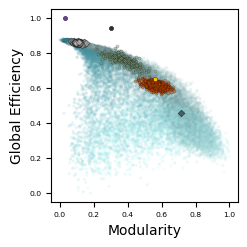

In [28]:
fig, axes = plt.subplot_mosaic(
"""
A
""",
figsize=viz.cm_to_inch((6,6)),
layout="constrained",
)

# ── Scatter panels A–D ────────────────────────────────────────────────────

# for panel_id, pcfg in cfg["scatter_panels"].items():
ax = axes["A"]

for dataset in datasets_to_plot:
    if (not INCLUDE_LEXIS) and ("lexi" in dataset):
        continue

    df_merged = dict_with_all_datasets[dataset]
    x_col, y_col = "modularity", "global_efficiency" # pcfg["x"], pcfg["y"]
    if x_col not in df_merged.columns or y_col not in df_merged.columns:
        continue

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
    is_kaysons = "kaysons" in dataset
    is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")

    ax.scatter(
        df_merged[x_col],
        df_merged[y_col],
        color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.4 if is_reference else 0.25 if not is_gnm else 0,
        s=12 if is_reference else 10 if is_kaysons else 5,
        marker="D" if is_reference else "o",
        alpha=0.15 if is_gnm else 0.6 if is_reference else 1.0 if is_kaysons else 0.4,
        label=LABEL_MAP[dataset], #  if panel_id == "A" else None,
        zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
        rasterized=is_gnm,
    )

ax.set_xlabel(PROPERTY_NAMES.get(x_col, x_col)) # ), fontsize=6.5)
ax.set_ylabel(PROPERTY_NAMES.get(y_col, y_col)) # ), fontsize=6.5)
ax.tick_params(labelsize=5.5)
# ax.set_title(f"{panel_id}  {pcfgq['title']}", fontsize=7, loc="left")

fig.savefig(output_folder / f"scatter_test_{x_col}_{y_col}.pdf")
print(f"{output_folder / f'scatter_test_{x_col}_{y_col}.pdf'}")
plt.show()


In [29]:
COLOR_SCHEME

{'hcp_schaefer_100_dataset_gnm': '#232324',
 'hcp_schaefer_100_dataset': '#4BAE6A',
 'kaysons_generated_networks_diffusion': '#F7BE18',
 'kaysons_generated_networks_propagation': '#262F3F',
 'kaysons_generated_networks_routing': '#6E3AA3',
 'kaysons_generated_networks_topology': '#394D73',
 'ring_lattice_networks': '#1a1f1f',
 'erdos_renyi_networks': '#B8B8B8',
 'suarez_MaMI_dataset': '#799372',
 'lexis_data_young': '#BD3B1A',
 'lexis_data_aging': '#5E1E0C',
 'lexis_data_developing': '#C74800',
 'lexis_data_developing_consensus_per_age_1_year': '#A6587C',
 'lexis_data_young_consensus_per_age_1_year': '#5DC400',
 'lexis_data_aging_consensus_per_age_1_year': '#E8D43C',
 'lexis_data_all_consensus_per_age_1_year': '#4BAE6A',
 'lexis_data_all_consensus_per_age_2_year': '#4BAE6A'}

In [30]:
def scatters(x_col, y_col): 
    fig, axes = plt.subplot_mosaic(
    """
    A
    """,
    figsize=viz.cm_to_inch((6,6)),
    layout="constrained",
    )

    # ── Scatter panels A–D ────────────────────────────────────────────────────

    # for panel_id, pcfg in cfg["scatter_panels"].items():
    ax = axes["A"]

    for dataset in datasets_to_plot:
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            continue

        df_merged = dict_with_all_datasets[dataset]
        # x_col, y_col = "modularity", "global_efficiency" # pcfg["x"], pcfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
        is_kaysons = "kaysons" in dataset
        is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.4 if is_reference else 0.25 if not is_gnm else 0,
            s=12 if is_reference else 10 if is_kaysons else 5,
            marker="D" if is_reference else "o",
            alpha=0.15 if is_gnm else 0.6 if is_reference else 1.0 if is_kaysons else 0.4,
            label=LABEL_MAP[dataset], #  if panel_id == "A" else None,
            zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(x_col, x_col)) # ), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(y_col, y_col)) # ), fontsize=6.5)
    ax.tick_params(labelsize=5.5)
    # ax.set_title(f"{panel_id}  {pcfgq['title']}", fontsize=7, loc="left")

    fig.savefig(output_folder / f"scatter_test_{x_col}_{y_col}.pdf")
    print(f"{output_folder / f'scatter_test_{x_col}_{y_col}.pdf'}")
    plt.show()


In [31]:
for k in df_merged.keys(): 
    print(k)

transitivity
avg_clustering
modularity
degree_gini
degree_assortativity
omega
structural_complexity
directed_simplices_count
directed_simplices_max_size
char_path_length
global_efficiency
diffusion_efficiency
propagation_efficiency
avg_communicability
topological_distance_mean
topological_distance_std
avg_edge_distance
wiring_cost
proportion_long_range_connections_0.1
proportion_long_range_connections_0.3
proportion_long_range_connections_0.3956
proportion_long_range_connections_0.5
richclub_n_edges
richclub_avg_length
rich_club_coefficient_rc_max_norm
rich_club_coefficient_rc_mean_norm
rich_club_coefficient_rc_k_at_max
rich_club_coefficient_rc_regime_frac
rich_club_coefficient_rc_weighted_auc
spectral_radius
spectral_gap
synchronizability_eigenratio_eigenratio
kernel_rank_thresholded_and_summed_0.01
kernel_rank_phase_diff_of_lambda_max_and_2nd
algebraic_connectivity_fiedler_value
algebraic_connectivity_fiedler_value_norm
algebraic_connectivity_laplacian_spectral_gap
algebraic_connecti

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_modularity_global_efficiency.pdf


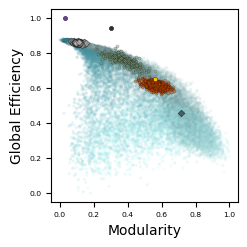

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_char_path_length_avg_clustering.pdf


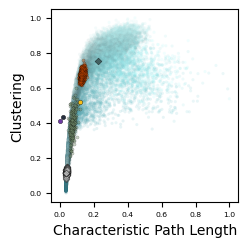

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_diffusion_efficiency_global_efficiency.pdf


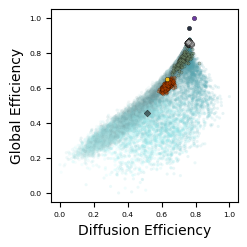

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_global_efficiency_propagation_efficiency.pdf


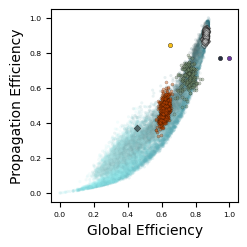

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_diffusion_efficiency_propagation_efficiency.pdf


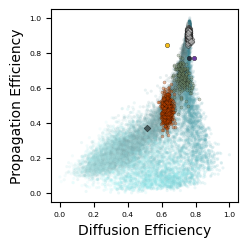

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_proportion_long_range_connections_0.3956_global_efficiency.pdf


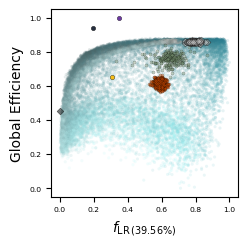

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_proportion_long_range_connections_0.3956_char_path_length.pdf


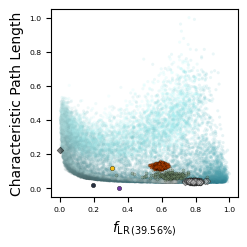

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_nct_control_std_targeted_attack_robustness_rob_random_auc.pdf


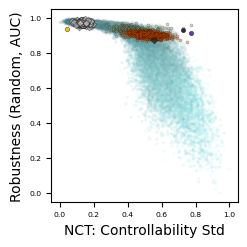

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_ipc_ipc_deg2_mean_ipc_ipc_deg1_mean.pdf


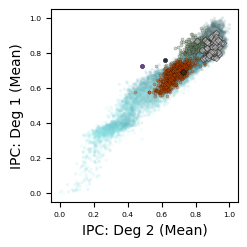

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_repertoire_sweep_weighted_by_distances_size_critical_ipc_ipc_deg1_mean.pdf


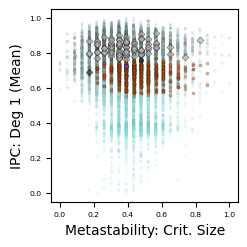

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_ipc_ipc_deg1_mean_targeted_attack_robustness_rob_targeted_auc.pdf


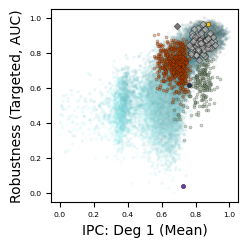

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_ipc_ipc_deg1_mean_targeted_attack_robustness_rob_random_auc.pdf


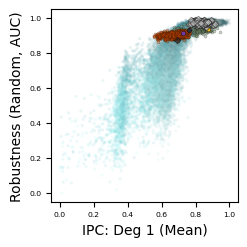

In [32]:
scatters("modularity", "global_efficiency")
scatters("char_path_length", "avg_clustering")
scatters("diffusion_efficiency", "global_efficiency")
scatters("global_efficiency", "propagation_efficiency")
scatters("diffusion_efficiency", "propagation_efficiency")
scatters("proportion_long_range_connections_0.3956", "global_efficiency")
scatters("proportion_long_range_connections_0.3956", "char_path_length")
scatters("nct_control_std", "targeted_attack_robustness_rob_random_auc")
scatters("ipc_ipc_deg2_mean", "ipc_ipc_deg1_mean")
scatters("repertoire_sweep_weighted_by_distances_size_critical", "ipc_ipc_deg1_mean")
scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_targeted_auc")
scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_random_auc")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_repertoire_sweep_weighted_by_distances_size_critical_ipc_ipc_deg1_mean.pdf


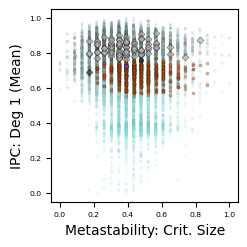

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_repertoire_sweep_weighted_by_distances_T_critical_ipc_ipc_deg1_mean.pdf


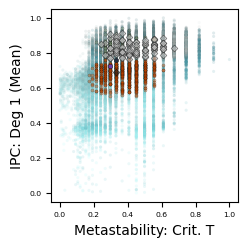

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_repertoire_sweep_weighted_by_distances_diversity_critical_ipc_ipc_deg1_mean.pdf


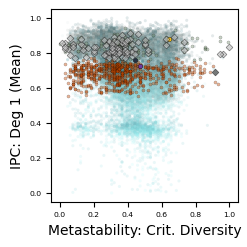

In [33]:
# scatters("ipc_ipc_deg2_mean", "ipc_ipc_deg1_mean")
# scatters("modularity", "global_efficiency")
# scatters("char_path_length", "avg_clustering")
# scatters("diffusion_efficiency", "global_efficiency")
# scatters("global_efficiency", "propagation_efficiency")
# scatters("diffusion_efficiency", "propagation_efficiency")
# scatters("proportion_long_range_connections_0.3956", "global_efficiency")
# scatters("proportion_long_range_connections_0.3956", "char_path_length")
# scatters("nct_control_std", "targeted_attack_robustness_rob_random_auc")
# scatters("ipc_ipc_deg2_mean", "ipc_ipc_deg1_mean")
scatters("repertoire_sweep_weighted_by_distances_size_critical", "ipc_ipc_deg1_mean")
scatters("repertoire_sweep_weighted_by_distances_T_critical", "ipc_ipc_deg1_mean")
scatters("repertoire_sweep_weighted_by_distances_diversity_critical", "ipc_ipc_deg1_mean")
# scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_targeted_auc")
# scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_random_auc")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_algebraic_connectivity_fiedler_value_targeted_attack_robustness_rob_targeted_auc.pdf


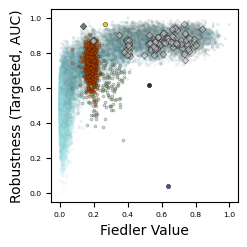

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_algebraic_connectivity_fiedler_value_targeted_attack_robustness_rob_random_auc.pdf


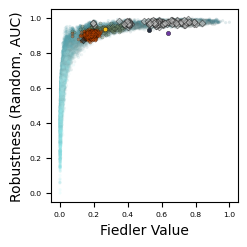

In [34]:
scatters("algebraic_connectivity_fiedler_value", "targeted_attack_robustness_rob_targeted_auc")
scatters("algebraic_connectivity_fiedler_value", "targeted_attack_robustness_rob_random_auc")
# scatters("char_path_length", "avg_clustering")
# scatters("diffusion_efficiency", "global_efficiency")
# scatters("global_efficiency", "propagation_efficiency")
# scatters("diffusion_efficiency", "propagation_efficiency")
# scatters("proportion_long_range_connections_0.3956", "global_efficiency")
# scatters("proportion_long_range_connections_0.3956", "char_path_length")
# scatters("nct_control_std", "targeted_attack_robustness_rob_random_auc")
# scatters("ipc_ipc_deg2_mean", "ipc_ipc_deg1_mean")
# scatters("repertoire_sweep_weighted_by_distances_size_critical", "ipc_ipc_deg1_mean")
# scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_targeted_auc")
# scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_random_auc")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_algebraic_connectivity_fiedler_value_targeted_attack_robustness_rob_targeted_auc.pdf


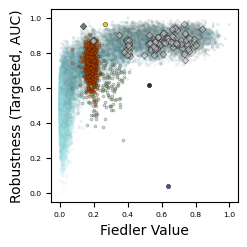

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/scatter_test_algebraic_connectivity_fiedler_value_targeted_attack_robustness_rob_random_auc.pdf


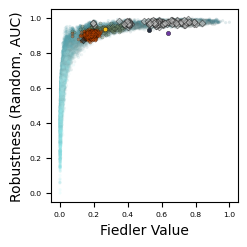

In [35]:
scatters("algebraic_connectivity_fiedler_value", "targeted_attack_robustness_rob_targeted_auc")
scatters("algebraic_connectivity_fiedler_value", "targeted_attack_robustness_rob_random_auc")

# scatters("char_path_length", "avg_clustering")
# scatters("diffusion_efficiency", "global_efficiency")
# scatters("global_efficiency", "propagation_efficiency")
# scatters("diffusion_efficiency", "propagation_efficiency")
# scatters("proportion_long_range_connections_0.3956", "global_efficiency")
# scatters("proportion_long_range_connections_0.3956", "char_path_length")
# scatters("nct_control_std", "targeted_attack_robustness_rob_random_auc")
# scatters("ipc_ipc_deg2_mean", "ipc_ipc_deg1_mean")
# scatters("repertoire_sweep_weighted_by_distances_size_critical", "ipc_ipc_deg1_mean")
# scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_targeted_auc")
# scatters("ipc_ipc_deg1_mean", "targeted_attack_robustness_rob_random_auc")

In [36]:
def draw_ternary_frame(ax, left_label, right_label, top_label):
    """Draw triangle boundary, gridlines, vertex labels, and axis direction arrows.

    Axes:
      bottom edge - left axis  (value increases right to left, toward TRI[0])
      left edge   - top axis   (value increases bottom to top, toward TRI[2])
      right edge  - right axis (value increases top to bottom-right, toward TRI[1])
    """
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0, 1, 2), (1, 2, 0), (2, 0, 1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="#d0d0d0", linewidth=0.4, zorder=1)

    fontsize = 8
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Axis direction arrows: one per axis, placed at the midpoint of the
    # corresponding edge, offset outward, pointing in direction of increasing value.
    _s32 = np.sqrt(3) / 2
    arrow_off = 0.09   # outward distance from edge midpoint
    arrow_arm = 0.10   # half-length of the arrow shaft

#     axis_arrows = [
#         # (edge midpoint,             increase direction,       outward normal)
#         # bottom edge: left axis increases from TRI[1] (0%) -> TRI[0] (100%)
#         ((_TRI[0] + _TRI[1]) / 2,  np.array([-1.0,   0.0]),  np.array([ 0.0, -1.0])),
#         # left edge:   top axis increases from TRI[0] (0%) -> TRI[2] (100%)
#         ((_TRI[0] + _TRI[2]) / 2,  np.array([ 0.5,   _s32]), np.array([-_s32,  0.5])),
#         # right edge:  right axis increases from TRI[2] (0%) -> TRI[1] (100%)
#         ((_TRI[1] + _TRI[2]) / 2,  np.array([ 0.5,  -_s32]), np.array([ _s32,  0.5])),
#     ]

#     for mid, inc_dir, out_norm in axis_arrows:
#         p = mid + out_norm * arrow_off
#         ax.annotate(
#             "",
#             xy=p + inc_dir * arrow_arm,
#             xytext=p - inc_dir * arrow_arm,
#             arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9, mutation_scale=7),
#             annotation_clip=False,
#         )

    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            left_label, ha="center", va="top", fontsize=6.5)
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            right_label, ha="center", va="top", fontsize=6.5)
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            top_label, ha="center", va="bottom", fontsize=6.5)

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# Triangles without converting it from wiring -> efficiency or so (needs to be done previously)


In [37]:
def triangle_scatters(left, right, top):    
    fig, axes = plt.subplot_mosaic(
    """
    A
    """,
    figsize=viz.cm_to_inch((9,9)),
    layout="constrained",
    )

    ax_t = axes["A"]
    draw_ternary_frame(ax_t, 
                    left_label=PROPERTY_NAMES[left], 
                    right_label=PROPERTY_NAMES[right],
                    top_label=PROPERTY_NAMES[top]) 


    cols = [left, right, top]

    # Global bounds from GNM (reference morphospace)
    gnm_cols = [c for c in cols if c in df_gnm.columns]

    _gnm_sub = df_gnm[cols].dropna()
    _global_min = np.array([
        # 1.0 - _gnm_sub[left].max() if cfg["invert_economy"] else _gnm_sub[left].min(),
        _gnm_sub[left].min(),
        _gnm_sub[right].min(),
        _gnm_sub[top].min(),
    ])
    _global_max = np.array([
        # 1.0 - _gnm_sub[left].min() if cfg["invert_economy"] else _gnm_sub[left].max(),
        _gnm_sub[left].max(),
        _gnm_sub[right].max(),
        _gnm_sub[top].max(),
    ])

    for dataset in datasets_to_plot:

        df_merged = dict_with_all_datasets[dataset]
        if not all(c in df_merged.columns for c in cols):
            continue

        raw = df_merged[cols].dropna()
        if len(raw) == 0:
            continue

        # v_left  = (1.0 - raw[left].values) if cfg["invert_economy"] else raw[left].values
        v_left  = raw[left].values
        v_right = raw[right].values
        v_top   = raw[top].values

        stack = np.column_stack([v_left, v_right, v_top])

        # Normalize using global GNM bounds
        for col_idx in range(3):
            rng = _global_max[col_idx] - _global_min[col_idx]
            if rng > 1e-12:
                stack[:, col_idx] = (stack[:, col_idx] - _global_min[col_idx]) / rng
            else:
                stack[:, col_idx] = 1.0 / 3.0
        stack = np.clip(stack, 0.0, 1.0)

        row_sums = stack.sum(axis=1, keepdims=True)
        row_sums[row_sums < 1e-12] = 1.0
        stack /= row_sums

        x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
        is_kaysons = "kaysons" in dataset
        is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")
        ax_t.scatter(
            x_cart, y_cart,
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.4 if is_reference else 0.2 if not is_gnm else 0,
            s=12 if is_reference else 10 if is_kaysons else 5,
            marker="D" if is_reference else "o",
            alpha=0.1 if is_gnm else 0.7 if is_reference else 1.0,
            zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
            rasterized=is_gnm,
        )
        
    plt.savefig(output_folder / f"ternary_scatter_{left}_{right}_{top}.pdf")
    print(f"{output_folder / f'ternary_scatter_{left}_{right}_{top}.pdf'}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_economic_efficiency_lr_propagation_efficiency_ipc_ipc_deg1_mean.pdf


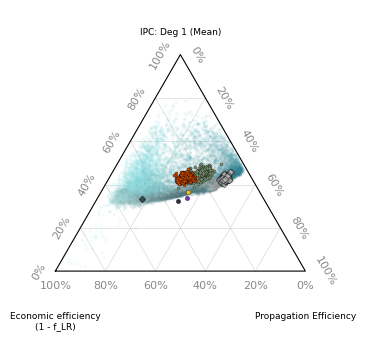

In [38]:
triangle_scatters("economic_efficiency_lr", "propagation_efficiency", "ipc_ipc_deg1_mean") # "economic_efficiency_lr", "economic_efficiency_wc", "algebraic_connectivity_fiedler_value")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_global_efficiency_mc_input_scaling_0_1_mc_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_global_efficiency_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_targeted_attack_robustness_rob_targeted_auc_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_targeted_attack_robustness_rob_random_auc_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_wiring_cost_algebraic_connectivity_fiedler_value_ipc_ipc_deg1_mean.pdf


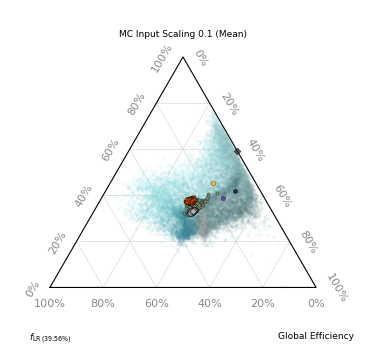

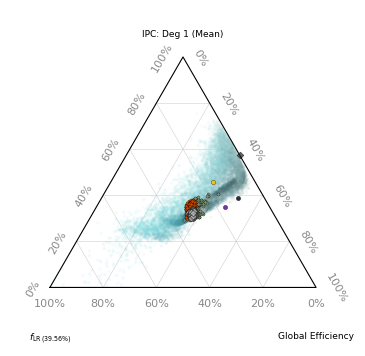

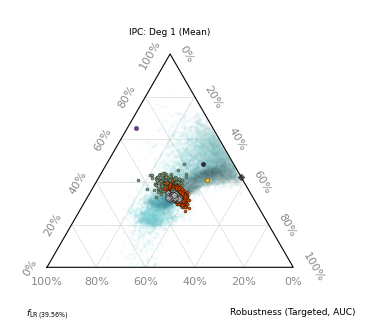

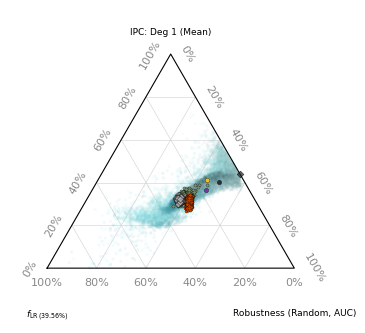

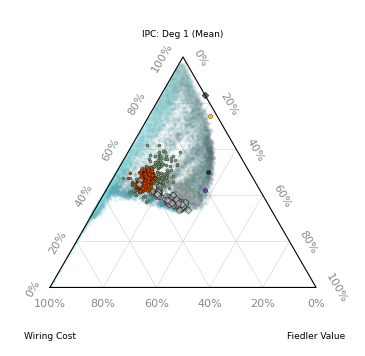

In [15]:
triangle_scatters("proportion_long_range_connections_0.3956", "global_efficiency", "mc_input_scaling_0_1_mc_mean")
triangle_scatters("proportion_long_range_connections_0.3956", "global_efficiency", "ipc_ipc_deg1_mean")
triangle_scatters("proportion_long_range_connections_0.3956", "targeted_attack_robustness_rob_targeted_auc", "ipc_ipc_deg1_mean")
triangle_scatters("proportion_long_range_connections_0.3956", "targeted_attack_robustness_rob_random_auc", "ipc_ipc_deg1_mean")
triangle_scatters("wiring_cost", "algebraic_connectivity_fiedler_value", "ipc_ipc_deg1_mean")



/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_global_efficiency_diffusion_efficiency_propagation_efficiency.pdf


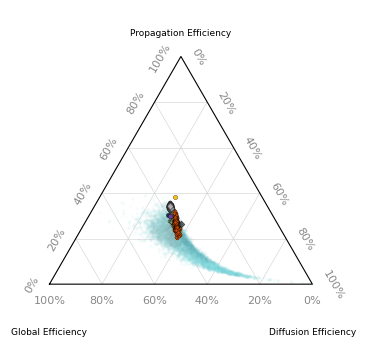

In [16]:
    # "economy":  "global_efficiency", # corr too highly with omega
    # "robustness": "diffusion_efficiency",
    # "computation": "propagation_efficiency",

triangle_scatters("global_efficiency", "diffusion_efficiency", "propagation_efficiency")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_economic_efficiency_lr_algebraic_connectivity_fiedler_value_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_economic_efficiency_wc_algebraic_connectivity_fiedler_value_ipc_ipc_deg1_mean.pdf


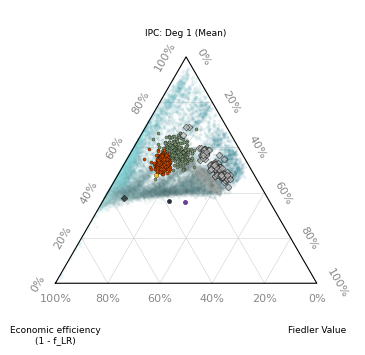

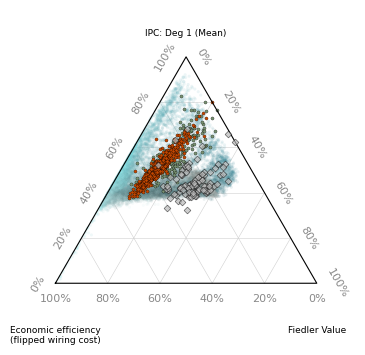

In [17]:
triangle_scatters("economic_efficiency_lr", "algebraic_connectivity_fiedler_value", "ipc_ipc_deg1_mean")
triangle_scatters("economic_efficiency_wc", "algebraic_connectivity_fiedler_value", "ipc_ipc_deg1_mean")

# PROPERTY_NAMES["economic_efficiency_lr"] = "Economic efficiency (1 − f_LR)"
# PROPERTY_NAMES["economic_efficiency_wc"] = "Economic efficiency (wiring cost)"

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_global_efficiency_mc_input_scaling_0_1_mc_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_global_efficiency_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_targeted_attack_robustness_rob_targeted_auc_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_proportion_long_range_connections_0.3956_targeted_attack_robustness_rob_random_auc_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_wiring_cost_algebraic_connectivity_fiedler_value_ipc_ipc_deg1_mean.pdf


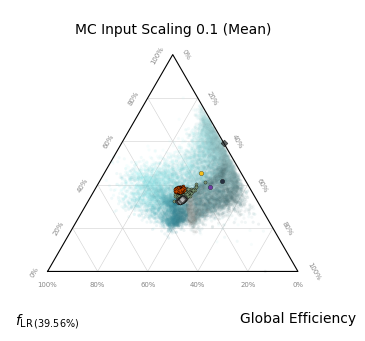

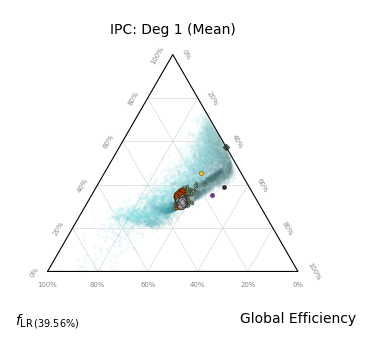

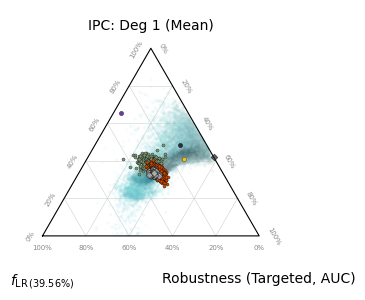

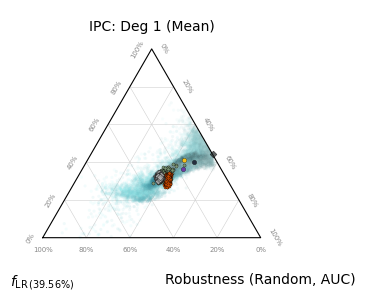

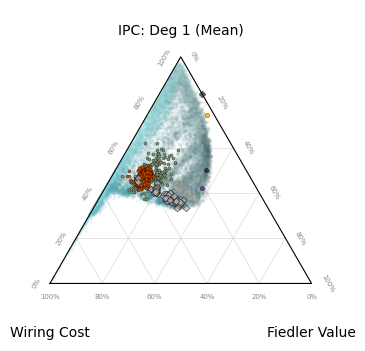

In [18]:

def draw_ternary_frame(ax, left_label, right_label, top_label):                
      """Draw triangle boundary, gridlines, vertex labels, and axis direction     
  arrows.                                             
                                                                                  
      Axes:                                                                       
        bottom edge - left axis  (value increases right to left, toward TRI[0])  
        left edge   - top axis   (value increases bottom to top, toward TRI[2])   
        right edge  - right axis (value increases top to bottom-right, toward    
  TRI[1])                                                                         
      """                                                                        
      tri_closed = np.vstack([_TRI, _TRI[0]])                                    
      ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8,   
  zorder=5)
                                                                                  
      for f in [0.2, 0.4, 0.6, 0.8]:                                              
          for i, j, k in [(0, 1, 2), (1, 2, 0), (2, 0, 1)]:                      
              p0 = (1 - f) * _TRI[i] + f * _TRI[j]                                
              p1 = (1 - f) * _TRI[i] + f * _TRI[k]                                
              ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="#d0d0d0",           
  linewidth=0.4, zorder=1)                                                        
                                                                                 
      fontsize = 5                                                                
      offset = 0.04                                                              
      for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:                                   
          px = (1 - f) * _TRI[0] + f * _TRI[1]                                    
          ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                  ha="center", va="top", fontsize=fontsize, color="#888888")      
          pl = (1 - f) * _TRI[0] + f * _TRI[2]                                   
          ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",                        
                  ha="right", va="center", fontsize=fontsize, color="#888888",    
                  rotation=60)                                                                   
          pr = (1 - f) * _TRI[1] + f * _TRI[2]                                    
          ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",                      
                  ha="left", va="center", fontsize=fontsize, color="#888888",    
                 rotation=-60)                                                                   
                                                                                 
#       # Axis direction arrows: one per axis, placed at the midpoint of the        
#       # corresponding edge, offset outward, pointing in direction of increasing value.                                                                          
#       _s32 = np.sqrt(3) / 2                                                      
#       arrow_off = 0.09   # outward distance from edge midpoint                   
#       arrow_arm = 0.10   # half-length of the arrow shaft                         
   
#       axis_arrows = [                                                             
#           # (edge midpoint,             increase direction,       outward normal)
#           # bottom edge: left axis increases from TRI[1] (0%) -> TRI[0] (100%)   
#           ((_TRI[0] + _TRI[1]) / 2,  np.array([-1.0,   0.0]),  np.array([ 0.0,    
#   -1.0])),
#           # left edge:   top axis increases from TRI[0] (0%) -> TRI[2] (100%)     
#           ((_TRI[0] + _TRI[2]) / 2,  np.array([ 0.5,   _s32]), np.array([-_s32,   
#   0.5])),                                                                         
#           # right edge:  right axis increases from TRI[2] (0%) -> TRI[1] (100%)   
#           ((_TRI[1] + _TRI[2]) / 2,  np.array([ 0.5,  -_s32]), np.array([ _s32,   
#   0.5])),                                                                         
#       ]                                                                          
                                                                                  
#       for mid, inc_dir, out_norm in axis_arrows:                                 
#           p = mid + out_norm * arrow_off                                         
#           ax.annotate(
#               "",                                                                 
#               xy=p + inc_dir * arrow_arm,
#               xytext=p - inc_dir * arrow_arm,                                     
#               arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9,          
#   mutation_scale=7),                                                              
#               annotation_clip=False,
#           )                                                                       
                                                                                 
      label_offset = 0.09                                                        
      ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
              left_label, ha="center", va="top") # , fontsize=6.5)
      ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,                        
              right_label, ha="center", va="top") # , fontsize=6.5)
      ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,                        
              top_label, ha="center", va="bottom") # , fontsize=6.5)                 
                                                                                  
      ax.set_xlim(-0.15, 1.15)                                                    
      ax.set_ylim(-0.22, _TRI[2][1] + 0.18)                                      
      ax.set_aspect("equal")                                                      
      ax.axis("off")           
    
    # plt.savefig(output_folder / f"ternary_frame_test_{}.pdf")
    # print(f"{output_folder / f'ternary_frame_test.pdf'}")                                                  
                      
                      
triangle_scatters("proportion_long_range_connections_0.3956", "global_efficiency", "mc_input_scaling_0_1_mc_mean")
triangle_scatters("proportion_long_range_connections_0.3956", "global_efficiency", "ipc_ipc_deg1_mean")
triangle_scatters("proportion_long_range_connections_0.3956", "targeted_attack_robustness_rob_targeted_auc", "ipc_ipc_deg1_mean")
triangle_scatters("proportion_long_range_connections_0.3956", "targeted_attack_robustness_rob_random_auc", "ipc_ipc_deg1_mean")
triangle_scatters("wiring_cost", "algebraic_connectivity_fiedler_value", "ipc_ipc_deg1_mean")


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_economic_efficiency_lr_global_efficiency_ipc_ipc_deg1_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_economic_efficiency_lr_global_efficiency_mc_input_scaling_0_1_mc_mean.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_26217/2861700102.py:12: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/ternary_scatter_economic_efficiency_wc_global_efficiency_mc_input_scaling_0_1_mc_mean.pdf


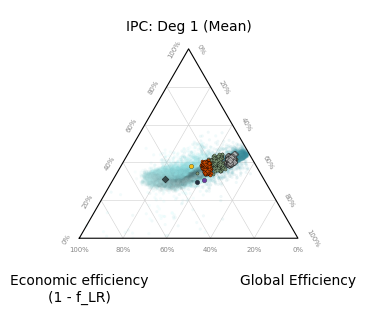

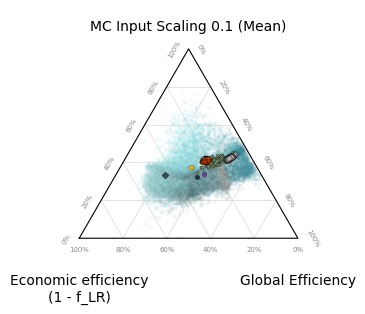

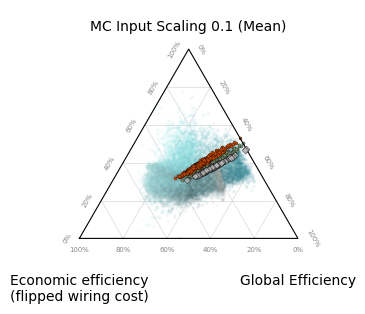

In [19]:

triangle_scatters("economic_efficiency_lr",
                  "global_efficiency",
                  "ipc_ipc_deg1_mean")

triangle_scatters("economic_efficiency_lr",
                  "global_efficiency",
                  "mc_input_scaling_0_1_mc_mean")

triangle_scatters("economic_efficiency_wc",
                  "global_efficiency",
                  "mc_input_scaling_0_1_mc_mean")

In [20]:
# # ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────
# from config import PROPERTY_NAMES

# trade_off_panels = {
#     "A": {
#         "x": "global_efficiency",
#         "y": "modularity",
#         "title": "Integration vs. Segregation",
#         "ref": "Sporns & Betzel, 2016",
#     },
#     "B": {
#         "x": "proportion_long_range_connections_0.3956",
#         "y": "global_efficiency",
#         "title": "Economy vs. Efficiency",
#         "ref": "Bullmore & Sporns, 2012",
#     },
#     "C": {
#         "x": "char_path_length",
#         "y": "avg_clustering",
#         "title": "Small-World Plane",
#         "ref": "Watts & Strogatz, 1998",
#     },
#     # "C": {
#     #     "x": "algebraic_connectivity_fiedler_value", # "algebraic_connectivity_nx",
#     #     "y": "modularity",
#     #     "title": "Robustness vs. Segregation",
#     #     "ref": "see e.g. Sporns, 2013",
#     # },
#     "D": {
#         "x": "diffusion_efficiency",
#         "y": "global_efficiency", 
#         "title": "",
#         "ref": "",
#     },
#     "E": {
#         "x": "diffusion_efficiency",
#         "y": "propagation_efficiency", 
#         "title": "",
#         "ref": "",
#     },
#     "F": {
#         "x": "global_efficiency",
#         "y": "propagation_efficiency", 
#         "title": "",
#         "ref": "",
#     },
#     # "D": {
#     #     "x": "computational_capacity_memory_capacity_total",
#     #     "y": "computational_capacity_nonlinear_capacity_total",
#     #     "title": "Memory vs. Nonlinear Computation",
#     #     "ref": "Dambre et al., 2012",
#     # },
#     # "E": {
#     #     "x": "char_path_length",
#     #     "y": "avg_clustering",
#     #     "title": "Small-World Plane",
#     #     "ref": "Watts & Strogatz, 1998",
#     # },
#     # "F": {
#     #     "x": "global_efficiency",
#     #     "y":  "algebraic_connectivity_fiedler_value", # "targeted_attack_robustness_rob_targeted_auc",
#     #     "title": "Efficiency vs. Robustness",
#     #     "ref": "Albert et al., 2000",
#     # },
# }

# INCLUDE_LEXIS = True # False # True

# fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , layout="constrained")
# axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

# for panel_id, cfg in trade_off_panels.items():
#     ax = axes_grid[panel_id]

#     for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
#         df_merged = dict_with_all_datasets[dataset]
        
#         if (not INCLUDE_LEXIS) and ("lexi" in dataset):
#             print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
#             continue
        
#         x_col = cfg["x"]
#         y_col = cfg["y"]

#         if x_col not in df_merged.columns or y_col not in df_merged.columns:
#             continue

#         is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

#         ax.scatter(
#             df_merged[x_col],
#             df_merged[y_col],
#             color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
#             edgecolor="black" if not is_gnm else "none",
#             linewidth=0.25 if not is_gnm else 0,
#             s=5,
#             alpha=0.15 if is_gnm else 0.4,
#             label=LABEL_MAP[dataset] if panel_id == "A" else None,
#             zorder=1 if is_gnm else 2,
#             rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
#         )

#     # Axis labels from PROPERTY_NAMES (fall back to raw name)
#     ax.set_xlabel(PROPERTY_NAMES[cfg["x"]]) # .replace(" ", "\n")) # .get(cfg["x"], cfg["x"])) # , fontsize=7)
#     ax.set_ylabel(PROPERTY_NAMES[cfg["y"]]) # .replace(" ", "\n")) # .get(cfg["y"], cfg["y"])) # , fontsize=7)
#     ax.tick_params() # labelsize=6)

#     # Panel letter + title
#     # ax.set_title(f"{panel_id}  {cfg['title']}", # fontsize=7.5, fontweight="bold", 
#     #             #  loc="left"
#     #              )
#     ax.set_title(f"{cfg['title']}", # fontsize=7.5, fontweight="bold", 
#                 #  loc="left"
#                 )

#     # Reference annotation (bottom-right, small)
#     # ax.annotate(
#     #     cfg["ref"],
#     #     xy=(1, 0), xycoords="axes fraction",
#     #     # fontsize=4.5, 
#     #     color="gray",
#     #     ha="right", va="bottom",
#     # )

# # # Single shared legend from panel A
# # handles, labels = axes_grid["A"].get_legend_handles_labels()
# # fig.legend(
# #     handles, labels,
# #     # loc="outside lower", #  center",
# #     ncol=min(len(labels), 3),
# #     # fontsize=6,
# #     # markerscale=1.5,
# #     # frameon=False,
# #     bbox_to_anchor=(0.5, 0), 
# #     loc='upper center',
# # )

# plt.tight_layout()

# plt.savefig(output_folder / f"trade_off_grid_established_6_squares.pdf", bbox_inches="tight", dpi=300)
# print(output_folder / f"trade_off_grid_established_6_squares.pdf")
# plt.show()